In [1]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [2]:
import os
import HeST as hest
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection
from analysis.analysis_functions import *

# import astropy.stats as astat
from scipy.interpolate import interp1d



Starting the 0th direction
This is the hit [ True]


Starting the 1th direction
This is the hit [ True]


Starting the 2th direction
This is the hit [ True]


Starting the 3th direction
This is the hit [ True]


Starting the 4th direction
This is the hit [ True]


Starting the 5th direction
This is the hit [ True]


Starting the 6th direction
This is the hit [ True]


Starting the 7th direction
This is the hit [ True]


Starting the 8th direction
This is the hit [ True]


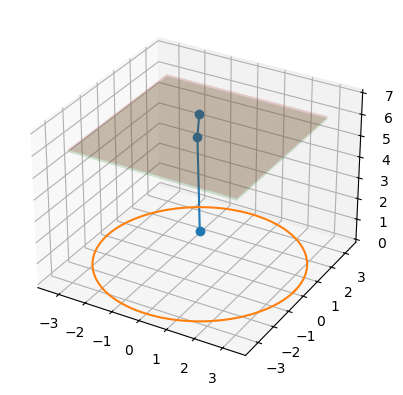

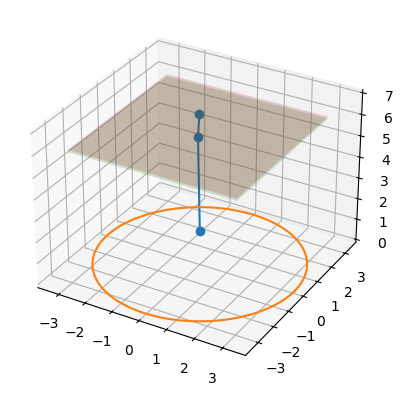

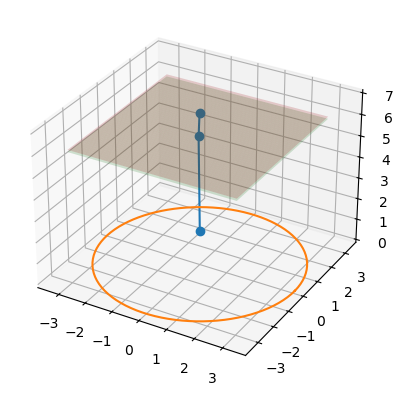

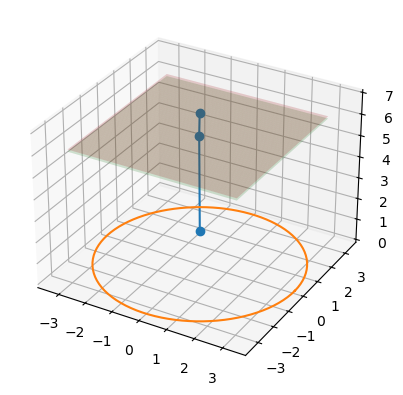

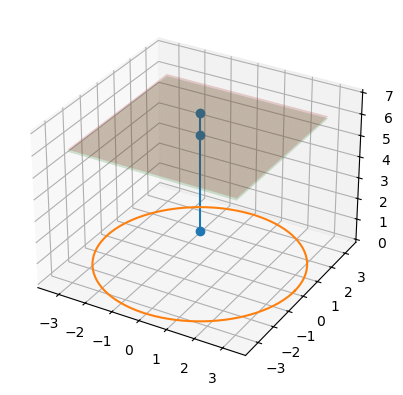

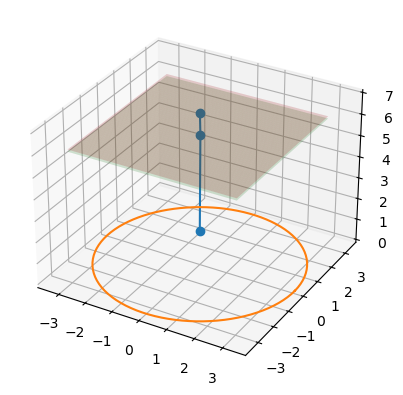

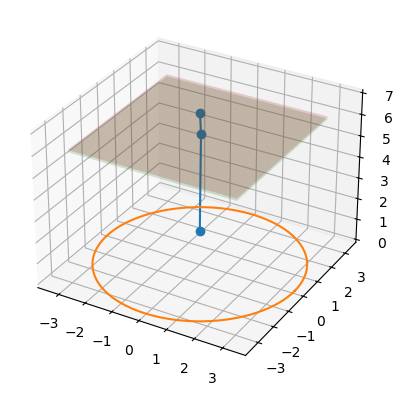

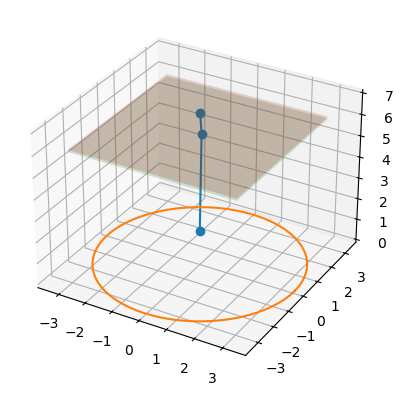

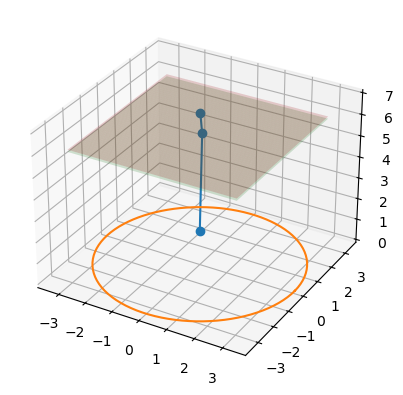

/tmp/ipykernel_3390406/2901633722.py:33: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(element[1][0,:][~mask], element[2][0,:][~mask], label = (round(directions_y[ii], 2), 1))


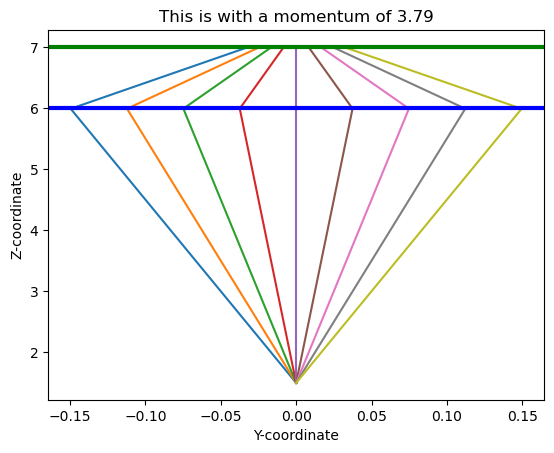

In [12]:
import HeST.optimize_6_10 as examp

detector = examp.Amherst_split_cpd 



detector.set_QP_reflection_prob(0.95)
detector.set_diffuse_prob(0.95)
# detector.set_evaporation_eff([0.0,0.0,0.125,0.0,0.5,0.0])
detector.set_evaporation_eff([1.0,1.0,1.0,1.0,1.0,1.0])




pos = [0.0, 0.0, 1.5]
moms = np.linspace(1.4, 4.7, 5)
directions_y = np.linspace(-0.1, 0.1, 9)
paths = []
mom =3.79
for ii, dirs in enumerate(directions_y):
    print('\n')
    print(f'Starting the {ii}th direction')
    useMap = False
    dir_unnormalized = np.array([0, dirs, 3])
    dir_unnormalized[1]= dirs
    dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
    evap = hest.GetEvaporationSignal( detector, 1, *pos, useMap=useMap, debug=True, debug_dir=dir,  plot_3d=True, choose_momentum=True, momentum_choice= mom, flavor_switching=True, verbose=False)
    paths.append(evap.positions)
plt.show()
plt.figure()
for ii, element in enumerate(paths):
    mask = (element[2][0,:] == 0)  & (element[1][0,:] == 0)
    plt.plot(element[1][0,:][~mask], element[2][0,:][~mask], label = (round(directions_y[ii], 2), 1))
plt.axhline(7.0, color ='g', lw = 3, label = 'CPD surface')
plt.axhline(6.0, color = 'b', lw = 3, label = 'liquid surface')
# plt.legend(loc = 'lower left')
plt.xlabel('Y-coordinate')
plt.ylabel('Z-coordinate')
plt.title(f'This is with a momentum of {mom}')
plt.show()

In [ ]:
evap.flavor

In [ ]:
import HeST.review_detector_big_setup as examp

detector = examp.Amherst_split_cpd 



detector.set_QP_reflection_prob(0.3)
detector.set_diffuse_prob(0.5)
detector.set_evaporation_eff(np.array([0.2,0.0,0.0,0.0,0.0,0.167]))

In [ ]:
pos = [0.0, 0.0, 1.75]
useMap = False
dir_unnormalized = np.array([1.0, 0.0,0.0])
dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
num_qps = int(50e4)

hits, arrival_times, paths= hest.GetEvaporationSignal(detector, num_qps, *pos, useMap=False, verbose=False, flavor_switching=True, save_hits_and_paths=True)

In [ ]:
plot_hist_flavors(evap)

In [ ]:
trial_data = np.column_stack((arrival_times, paths))

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14,6))
# at each point we want to do the histogram like we have been, AND a plot of the x-y arrival positions
ax1.set_title('Counts/location', fontsize=10)
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim(-3.6, 3.6)
ax1.set_ylim(-3.6, 3.6)
h, xe, ye, im = ax1.hist2d(trial_data[:,1], trial_data[:,2], bins=100, cmap='cividis')
fig.colorbar(im)
ax2.hist(trial_data[:,0], bins=200, range=(0,1500))
ax2.set_xlabel('Time [uS]')


In [ ]:
R_plus_mask = (evap.flavor[0] =='high energy Roton')


In [ ]:
plot_hist_flavors(evap)

In [ ]:
print(np.max(evap.momentum[0][R_plus_mask]))

In [ ]:
plt.scatter(evap.momentum[1], evap.arrivalTimes_us[1], s= 2)
plt.ylim(0, 500)

In [ ]:
pos = [0.0, 0.0, .1]
useMap = False
dir_unnormalized = np.array([1.0, 0.0,0.0])
dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))


hits, arrival_times, path = hest.GetEvaporationSignal( detector,2000000, *pos, useMap=useMap, debug=False, debug_dir=dir,  plot_3d=False, choose_momentum=False, momentum_choice= 2.7, verbose=False, flavor_switching=True, save_hits_and_paths=True)
# plot_stacked_hist(evap, plot_one=True)
print(path)

In [ ]:
print(path)

In [ ]:
x = np.linspace(1,5,5)
y = np.linspace(-1, 3, 5)
z = np.linspace(5, 9, 5)

paths = np.column_stack((x,y,z))
hits = np.array([True, True, False, False, False])

print(paths[hits])

t = np.linspace(0, 4, 5)

final = np.column_stack((t, paths))
print(final)

In [ ]:
pos = [0.0, 0.0, .1]
useMap = False
dir_unnormalized = np.array([1.0, 0.0,0.0])
dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
hits, arrival_times, paths= hest.GetEvaporationSignal(detector, 80000, *pos, useMap=False, verbose=False, flavor_switching=True, save_hits_and_paths=True)

final = np.column_stack((arrival_times, paths))


In [ ]:
plt.hist(arrival_times, bins=200, range=(0,1500))

In [ ]:
example = '[0.1 0.1 0.1 0.1]'
print(example[1:-1])
arg_list = np.fromstring(example[1:-1], sep=' ', dtype=float)
print(arg_list)

In [ ]:
x = [1.0, 1.5,.90, .75, .5, .15, -1.5]
y = [4.0, 0.5,.20, .75, .5, .15, -1.5]

np.arctan2(x,y)

In [ ]:
for i in range(2):
    print(i)

In [ ]:
def plot_hist_flavors(evap):
    # we need 3 masks
    fs = evap.flavor
    fig, axs = plt.subplots(1,2, figsize =(16, 4))
    for i in range(2):
        for value in np.unique(fs[i]):
            mask = (fs[i] == value)
            print(mask)
            axs[i].hist(evap.arrivalTimes_us[i][mask], bins = 200, range = [0,3000], alpha= 0.7,stacked=True, label = value)
            axs[i].set_title(f'CPD {i}')
            axs[i].legend(loc = 'upper right')
            # plt.hist(evap.arrivalTimes_us[0][mask], stacked=True, label = value + 'CPD2')
plot_hist_flavors(evap)

In [ ]:
critical_angles = np.array([-0.99914392,  -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392])

random_numbs = np.array([-0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392])
print((critical_angles > 1.19028995) & (random_numbs > 1.0))

/tmp/ipykernel_1739721/2452667038.py:4: RuntimeWarning: invalid value encountered in sqrt
  return np.arcsin(1 * np.sqrt(2 * m * (Energy - binding_energy))/np.abs(momentum))
/tmp/ipykernel_1739721/2452667038.py:4: RuntimeWarning: invalid value encountered in arcsin
  return np.arcsin(1 * np.sqrt(2 * m * (Energy - binding_energy))/np.abs(momentum))


Text(0.5, 1.0, 'Critical Evaporation Angle')

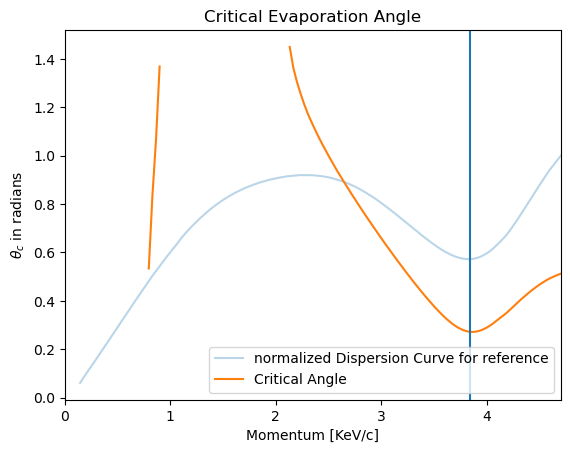

In [9]:
def critical_angle(Energy, momentum, binding_energy = 0.00062e-3):
    m =  3.725472e6 #He mass in keV/c^2
    c = 2.998e8
    return np.arcsin(1 * np.sqrt(2 * m * (Energy - binding_energy))/np.abs(momentum))
def GetInterpFunc(d_path):
    """Creates an linear interpolation function from data found at the file path below,, giving us the ability to convert from resistance to temperature. 
    returns:
        Interpoltion function: If input exceeds range of the data function returns a NaN"""
    data = np.loadtxt(d_path, delimiter=',')
    X = data[:,0]
    Y = data[:,1]
    return interp1d(X,Y, kind = 'linear')

def QP_dispersion(p ):
    """generate the energy of the particle in meV

    Args:
        p (int): the momentum of the quasiparticle of interest 
        interp (funct): function to relate momentum and energy  
    """
    interp = GetInterpFunc('./data/dispersion_curves/dispersion_data.csv')
    energy = interp(p)
    return energy * 1e-3 #This is in eV 

def QP_velocity(p ):
    interp = GetInterpFunc('./data/dispersion_curves/velocity_data.csv')
    velocity = interp(p)
    return velocity

momentum = np.linspace(0.145, 4.7, 134)
# # need to print the dispersion curve here too
# plt.plot(momentum, QP_dispersion(momentum))
# # plt.plot(momentum, QP_velocity(momentum))
# plt.xlabel('Momenutm [KeV/c]')
# plt.ylabel('Velocity [m/s]')
# plt.title('Velocity Dispersion')
energy = QP_dispersion(momentum) *1e-3 
# plt.figure()
plt.plot(momentum, QP_dispersion(momentum)/np.max(QP_dispersion(momentum)), alpha = 0.3, label = 'normalized Dispersion Curve for reference')
plt.plot(momentum, critical_angle(energy, momentum, binding_energy=0.00062e-3), label = 'Critical Angle')
plt.axvline(3.84)
plt.legend()
plt.xlim(0, 4.7)
plt.xlabel('Momentum [KeV/c]')
plt.ylabel(r'$\theta_c$ in radians')
plt.title('Critical Evaporation Angle')


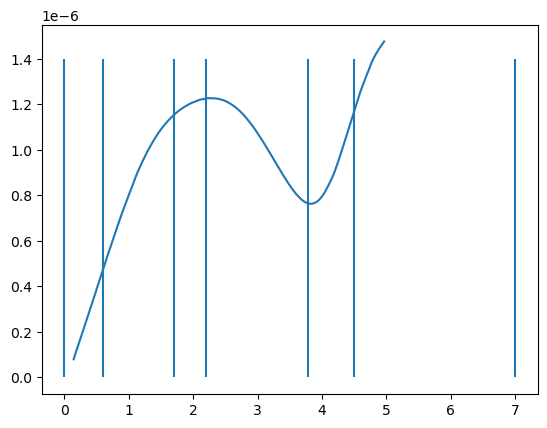

2.3062001180524505
3.840354441491354
7.629762092133456e-07


In [5]:
from scipy.interpolate import interp1d
data = np.loadtxt('./data/dispersion_curves/dispersion_data.csv', delimiter=',')
X = data[:,0]
Y = data[:,1] * 1e-6 # this is now in keV
dispersion= interp1d(X, Y)
plt.figure()
plt.plot(X, Y)

plt.vlines(x=[0.0, 0.6, 1.7, 2.2, 3.78, 4.5, 7], ymin=0, ymax=1.4e-6)
plt.show()
print(X[63])
print(X[101])
print(dispersion(0.949))

In [ ]:
plt.rcParams.update({'font.size': 14})

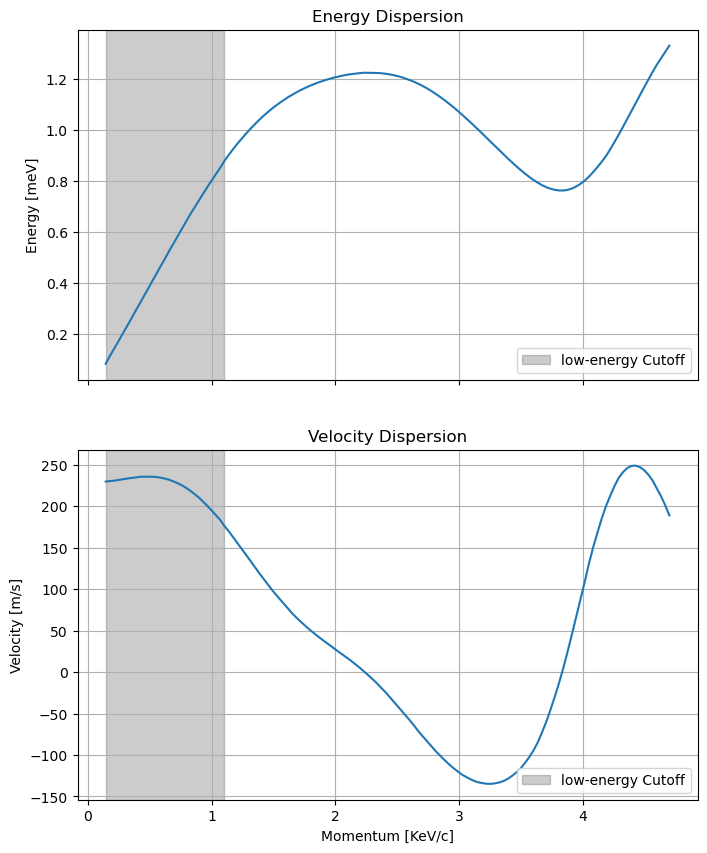

In [6]:

momentum = np.linspace(0.145, 4.7, 134)
fig, ax = plt.subplots(2,1, figsize = (8,10), sharex=True)


ax[0].plot(momentum, detection.QP_dispersion(momentum)*1e3)
ax[1].plot(momentum, detection.QP_velocity(momentum))
ax[1].set_xlabel("Momentum [KeV/c]")
ax[0].set_ylabel('Energy [meV]')
ax[1].set_ylabel('Velocity [m/s]')
ax[0].set_title('Energy Dispersion')
ax[1].set_title('Velocity Dispersion')
ax[0].grid()
ax[1].grid()

for i in range(2):
    ax[i].axvspan(0.145, 1.1, alpha = 0.2, color = 'black', label = 'low-energy Cutoff')
    ax[i].legend(loc='lower right')
fig.savefig('./data/plots/Dispersion_curve.png', dpi=250)


# plt.plot(momentum, detection.QP_velocity(momentum))
# plt.title('Liquid Helium Velocity Dispersion Curve')
# plt.xlabel('Momentum [KeV/c]')
# plt.ylabel('Velocity [meV]')
# plt.savefig('./data/plots/Dispersion_curve.png')

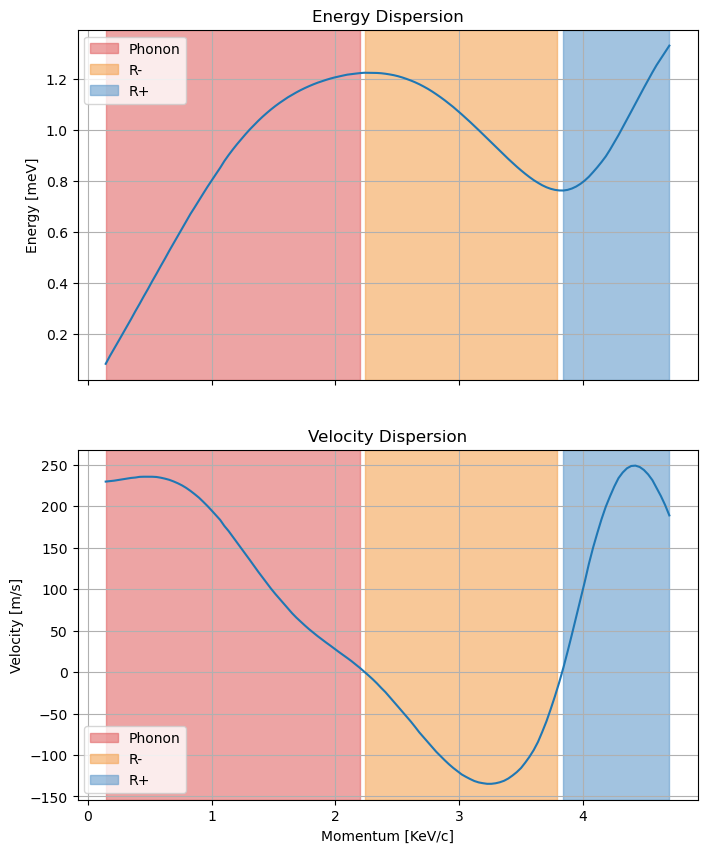

In [7]:

momentum = np.linspace(0.145, 4.7, 134)
fig, ax = plt.subplots(2,1, figsize = (8,10), sharex=True)

ax[0].plot(momentum, detection.QP_dispersion(momentum)*1e3)
ax[1].plot(momentum, detection.QP_velocity(momentum))
ax[1].set_xlabel("Momentum [KeV/c]")
ax[0].set_ylabel('Energy [meV]')
ax[1].set_ylabel('Velocity [m/s]')
ax[0].set_title('Energy Dispersion')
ax[1].set_title('Velocity Dispersion')
ax[0].grid()
ax[1].grid()

for i in range(2):
    # # ax[i].axvspan(0.145, 1.1, alpha = 0.2, color = 'black', label = 'low-energy Cutoff')
    ax[i].axvspan(0.145, 2.2, alpha = 0.6, color = '#e26768', label = 'Phonon')
    ax[i].axvspan(2.24,  3.789, alpha = 0.6, color = '#f4a454', label = 'R-')
    ax[i].axvspan(3.84,  4.70, alpha = 0.6, color = '#649ccc', label = 'R+')
    ax[i].legend()
fig.savefig('./data/plots/Dispersion_curve_with_flavors.png', dpi=250)


# plt.plot(momentum, detection.QP_velocity(momentum))
# plt.title('Liquid Helium Velocity Dispersion Curve')
# plt.xlabel('Momentum [KeV/c]')
# plt.ylabel('Velocity [meV]')
# plt.savefig('./data/plots/Dispersion_curve.png')

0.7624263496083991


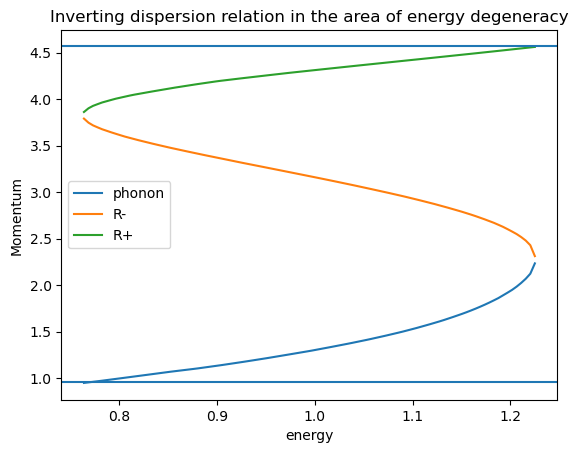

In [8]:
from scipy.signal import argrelextrema
def get_phonon_mom_energy(d_path):
    data = np.loadtxt(d_path, delimiter=',')
    X = data[0:63,1]
    Y = data[0:63,0]

    return interp1d(X,Y, kind = 'linear')
def get_rminus_mom_energy(d_path):
    data = np.loadtxt(d_path, delimiter=',')
    X = data[63:101,1]
    Y = data[63:101,0]
    return interp1d(X,Y, kind = 'linear')
def get_rplus_mom_energy(d_path):
    data = np.loadtxt(d_path, delimiter=',')
    X = data[101:,1]
    Y = data[101:,0]
    print(X[0])

    return interp1d(X,Y, kind = 'linear')

phonon_interp = get_phonon_mom_energy('./data/dispersion_curves/dispersion_data.csv')
rminus_interp = get_rminus_mom_energy('./data/dispersion_curves/dispersion_data.csv')
rplus_interp = get_rplus_mom_energy('./data/dispersion_curves/dispersion_data.csv')
energy = np.linspace(764, 1225, 100) * 1e-3 # This is meV
plt.plot(energy, phonon_interp(energy), label = 'phonon')
plt.plot(energy, rminus_interp(energy), label = 'R-')
plt.plot(energy, rplus_interp(energy), label = 'R+')
plt.xlabel('energy')
plt.ylabel('Momentum')
plt.title('Inverting dispersion relation in the area of energy degeneracy')
plt.legend()
plt.axhline(0.9555)
plt.axhline(4.565)

In [ ]:
print(rplus_interp(np.array(1.2259239975648981)))

In [ ]:
@np.vectorize
def assign_flavors(p):
    if .955 < p <   2.168:
        flavor = 'phonon'
    elif 2.383 < p < 3.77:
        flavor = 'R-'
    elif 3.843<p < 4.541:

        flavor = 'R+'
    else:
        flavor = 'out_of_range'
    return flavor
@np.vectorize
def compute_conserved_mom(X, Y, dx, dy, dz, momentum):
    direction = np.array([dx, dy, dz])
    xy_vec = -1 * np.array([X, Y, 0], dtype = float) # compute the normal vector of the wall
    xy_vec = xy_vec/(np.sqrt(np.sum(xy_vec**2))) # normalize this vector
    dir_transverse = direction- np.dot(direction, xy_vec) * xy_vec
    conserved_momentum= momentum * dir_transverse
    conserved_magnitude = np.sum(conserved_momentum**2)
    return conserved_magnitude

def random_conversion(energy, momentum, flavor, X, Y, Z, dx, dy, dz):
    """ This function handles the conversion process, which is done by randomely choosing new momentums, that match the original. 

    Args:
        energy (_type_): _description_
        momentum (_type_): _description_
        flavor (_type_): _description_
        pos (_type_): _description_
        direction (_type_): _description_

    Returns:
        _type_: _description_
    """
    # generate a set of random numbers 
    r_nums = np.random.uniform(low = 0, high= 1, size = (len(energy), 3))
    old_momentum = momentum
    print(f'old momentum {old_momentum}')
    # decide on who goes where
    phonon_mom = phonon_interp(energy)
    rminus_mom = rminus_interp(energy)
    rplus_mom = rplus_interp(energy)
    flavors = np.column_stack((np.full(np.shape(phonon_mom), r'phonon'), np.full(np.shape(phonon_mom), r'R-') , np.full(np.shape(phonon_mom), r'R+')))
    
    conserved_mom= compute_conserved_mom(X, Y, dx, dy, dz, old_momentum)
    # compute the conserved momentum, which is the momentum in this direction

    phonon_mask = phonon_mom**2 < conserved_mom 
    rminus_mask = rminus_mom**2 < conserved_mom
    rplus_mask = rplus_mom**2 < conserved_mom
    # generate arrays of flavors
    r_nums[:,0][phonon_mask] = 0
    r_nums[:,1][rminus_mask] = 0
    r_nums[:,2][rplus_mask] = 0
    momentums = np.column_stack((phonon_mom, rminus_mom, rplus_mom))
    max_indices = np.argmax(r_nums, axis=1)  # Correct indexing along rows
    momentum = momentums[np.arange(len(energy)), max_indices]  # Select momenta for each energy
    flavor = flavors[np.arange(len(energy)), max_indices]
    print(f'starting direction {dx, dy, dz}')
    dx, dy, dz= convert_off_XY(old_momentum, momentum, X, Y, Z, dx, dy, dz)
    return momentum, flavor, dx, dy, dz


@np.vectorize
def convert_off_XY(old_momentum, new_momentum, X, Y, Z, dx, dy, dz):
    """Handles the converting and reflection off of XY surface (the cylindrical area) based upon QP kinematics. 
    Conserves the translational momentum, but does the longitudinal momentum.

    Args:
        old_momentum (float): This is the old momentum, aka the input momentum to the system. This will be negative if the input QP was previously a R- roton. 
        new_momentum (_type_): This is the new momentum, after conversion. This should be negative if the desired QP output is a R- roton. 
        pos (tuple or ndarray): This is the position of intersection with the wall
        direction (tuple or ndarray): This is the incident direction 
    """
    direction = np.array([dx, dy, dz])
    xy_vec = -1 * np.array([X, Y, 0], dtype = float) # compute the normal vector of the wall
    xy_vec = xy_vec/(np.sqrt(np.sum(xy_vec**2))) # normalize this vector
    dir_transverse = direction- np.dot(direction, xy_vec) * xy_vec
    # compute the conserved momentum, which is the momentum in this direction
    conserved_mom_parallel= old_momentum* dir_transverse
    print(f'Conserved momentum = {conserved_mom_parallel}')
    new_momentum_parallel= np.sqrt(new_momentum**2 - np.sum(conserved_mom_parallel**2))
    if new_momentum < 0:
        new_momentum_parallel = new_momentum_parallel *-1
    new_total_mom_vec = new_momentum_parallel * xy_vec + conserved_mom_parallel
    print(f'new momentum: {new_total_mom_vec}')
    new_total_mom_vec = new_total_mom_vec/new_momentum
    direction = new_total_mom_vec/np.linalg.norm(new_total_mom_vec, ord = 2)
    print(f'new direction {direction}')
    return direction[0], direction[1], direction[2]


    
def reflection(momentum, energy, pos, direction, flavor, surface):
    new_mom = random_conversion(energy, momentum)
    flavor = assign_flavors(new_mom)
        




    


   

In [ ]:
random_conversion(momentum=np.array([1.0,1.2,3.0]),energy=np.array([0.00080141, 0.00094112, 0.00107])*1e3, flavor=['phonon', 'phonon', 'phonon'], X = [3.0, -3.0, -3.0],Y= [0,0,0],Z = [1.5, 1.5, 1.5], dx = [1.0, 1.0, 1/np.sqrt(3)], dy = [0,0,-1/np.sqrt(3)],dz = [0,0,1/np.sqrt(3)])

In [ ]:
def random_conversion_off_z(energy, momentum, old_flavor, dx, dy, dz):
    """Handles the random flavor switching off a surface of surface type 'Z'

    Args:
        energy (array): This should be in units of eV 
        momentum (array): This should be in units of KeV/c, and it should have the same dimension as energy
        old_flavor (_type_): Describes the flavor of each QP, and it has the same dimension as the energy array. 
        dx (array): direction in x 
        dy (array): direction in y
        dz (array): Direction in Z

    Returns:
        _type_: _description_
    """

    r_nums = np.random.uniform(low = 0, high= 1, size = (len(energy), 3))
    old_momentum = momentum
    # decide on who goes where
    phonon_mom = phonon_interp(energy * 1e3)
    rminus_mom = rminus_interp(energy * 1e3)
    rplus_mom = rplus_interp(energy * 1e3)
    flavors = np.column_stack((np.full(np.shape(phonon_mom), r'phonon'), np.full(np.shape(phonon_mom), r'R-') , np.full(np.shape(phonon_mom), r'R+')))
    
    cons_x = momentum * dx
    cons_y = momentum * dy
    # compute the conserved momentum, which is the x,y momentum in this direction
    conserved_mom_sq = (cons_x**2 + cons_y**2) 
    print('conserved momentum:')
    print(conserved_mom_sq)
    phonon_mask = phonon_mom**2 < conserved_mom_sq 
    rminus_mask = rminus_mom**2 < conserved_mom_sq
    rplus_mask = rplus_mom**2 < conserved_mom_sq
    print('masks')
    print(phonon_mask, rminus_mask, rplus_mask)
    # generate arrays of flavors
    r_nums[:,0][phonon_mask] = 0
    r_nums[:,1][rminus_mask] = 0
    r_nums[:,2][rplus_mask] = 0 
    momentums = np.column_stack((phonon_mom, -1 * rminus_mom, rplus_mom))
    print('momentums')
    print(momentums)
    max_indices = np.argmax(r_nums, axis=1)  # Correct indexing along rows
    print('random numbers')
    print(r_nums)
    momentum = momentums[np.arange(len(energy)), max_indices]  # Select momenta for each energy
    flavor = flavors[np.arange(len(energy)), max_indices]
    no_change_mask = (flavor == old_flavor)
    print('final flavor and masks')
    print(flavor, no_change_mask)
    if any(~no_change_mask): 
        print('changing momentum was called')
        dx[~no_change_mask], dy[~no_change_mask], dz[~no_change_mask] = conserve_z(momentum[~no_change_mask], conserved_mom_sq[~no_change_mask], 
                                                                                   dx[~no_change_mask], dy[~no_change_mask], dx[~no_change_mask])
    print('final direction vector')
    print(dx, dy, dz)
    return momentum, flavor, dx, dy, dz

@np.vectorize
def conserve_z(momentum, conserved_mom, dx, dy, dz):
    dz_prime = np.sqrt(momentum**2 - conserved_mom)
    # pack them together
    new_direction_vec = np.array([dx, dy, dz_prime])
    # normalize
    new_direction_vec = new_direction_vec/np.linalg.norm(new_direction_vec)
    if momentum < 0:
        new_direction_vec[0] = -1 * new_direction_vec[0]  
        new_direction_vec[1] = -1 * new_direction_vec[1]  
    return new_direction_vec[0], new_direction_vec[1], new_direction_vec[2] 

In [ ]:
dir_unnormalized = np.array([10.0,0 ,1.0])
dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
print('Direction:')
print(dir)
random_conversion_off_z(np.array([0.8]) * 1e-3, np.array([0.998076708935354]), 'phonon', np.array([dir[0]]),np.array([dir[1]]),np.array([dir[2]]))


In [ ]:
-0.27517052 * -3.61554875

In [ ]:
print(phonon_interp(800.0 * 1e-3))
print(rplus_interp(800.0 * 1e-3))
print(rminus_interp(800.0 * 1e-3))

In [ ]:
@np.vectorize
def assign_flavors(p, flavor):
    if .955 < p <   2.168:
        flavor = 'phonon'
    if 2.383 < p < 3.77:
        flavor = 'R-'
    if 3.843<p < 4.541:

        flavor = 'R+'
    return flavor




In [ ]:
# I'm trying to figure out why this isn't working
X = [2.22, -1.34]
Y = [0, 2.67]
t = np.linspace(0, 5, 100)
path_x = []
path_y = []
for time in t:
    path_x.append(-0.34979062 * time - 1.34)
    path_y.append(-0.9368279* time +2.67)
plt.plot(path_x, path_y, label = 'new direction')
plt.plot(X, Y, label = 'final point')
plt.legend()

In [ ]:
flavor = np.full(10, 'out_of_degenerate_range')
momentum = np.random.uniform(low = .147, high = 4.7, size=10)
print(assign_flavors(momentum, flavor))

In [ ]:
plt.hist(evap.num_bounces, bins=20 )
plt.yscale('log')
plt.xlabel('number of bounces')
plt.ylabel('Counts per num of bounce')
plt.title('Understanding if we are gettign the expected number of bounces')
print(np.mean(evap.num_bounces))

In [ ]:
pos = [0., 0., 1.5]
useMap = False
evap = hest.GetEvaporationSignal( detector, 10, *pos, useMap=useMap, debug=False, plot_3d=True)


In [ ]:
plot_stacked_hist(evap)


In [ ]:
pos = [0., 0., 1.5]
useMap = False
evap = hest.GetEvaporationSignal( detector,1000, *pos, useMap=useMap, debug=False, plot_3d=False)
plot_stacked_hist(evap=evap)


# Status Update
At this point, everything above this is fully being used to 'flush' out, and as an active debugging site. Below this we will be beginning to run tests of the code, and this way I can save it for the future

In [ ]:
import HeST.optimize_6_1 as examp

In [ ]:

detector = examp.Amherst_split_cpd 



detector.set_QP_reflection_prob(1.0)
detector.set_diffuse_prob(0.0)
detector.set_evaporation_eff([1.0] * 6)

This code block is dedicated towards making a bunch of plots of the paths, where we are varying the momentum (with the same set of directions)

It is important to note that it saves this is a path _plots/adams-thesis_recreation_ with the name value of momentum + _xy.png_

In [ ]:
import HeST.optimize_6_1 as examp

detector = examp.Amherst_split_cpd 



detector.set_QP_reflection_prob(1.0)
detector.set_diffuse_prob(0.0)
detector.set_evaporation_eff([1.0] * 6)




pos = [0.0, 0.0, 1.5]
moms = np.linspace(1.4, 4.7, 5)
directions_y = np.linspace(2, -2, 9)
paths = []
mom =4.4
for ii, dirs in enumerate(directions_y):
    print('\n')
    print(f'Starting the {ii}th direction')
    useMap = False
    dir_unnormalized = np.array([0, 1, 1])
    dir_unnormalized[1]= dirs
    dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
    evap = hest.GetEvaporationSignal( detector, 1, *pos, useMap=useMap, debug=True, debug_dir=dir,  plot_3d=True, choose_momentum=True, momentum_choice= mom, verbose= True)
    paths.append(evap.positions)
plt.show()
plt.figure()
for ii, element in enumerate(paths):
    print(element[2][0,:])
    mask = (element[2][0,:] == 0)  & (element[1][0,:] == 0)
    plt.plot(element[1][0,:][~mask], element[2][0,:][~mask], label = (round(directions_y[ii], 2), 1))
plt.axhline(3.3, color ='g', lw = 3, label = 'CPD surface')
plt.axhline(2.75, color = 'b', lw = 3, label = 'liquid surface')
plt.legend(loc = 'lower left')
plt.xlabel('Y-coordinate')
plt.ylabel('Z-coordinate')
plt.title(f'This is with a momentum of {mom}')
plt.savefig(os.path.join('plots', 'adams-thesis_recreation',  str(mom) + 'xy.png'))
plt.show()

now we want to make a similar code block, except where we are varying the height of the liquid. 

In [ ]:

detector = examp.Amherst_split_cpd 
pos = [0.0, 0.0, 1.5]
QP_conditions= detector.get_surface_conditions()
nCPDs = detector.get_nCPDs()
for i in range(nCPDs):
    QP_conditions.append( (detector.get_CPD(i)).get_surface_condition() )
detector.set_QP_reflection_prob(0.80)
detector.set_diffuse_prob(0.0)
detector.set_evaporation_eff(1.0)

directions_y = np.linspace(-1, 1, 10, dtype=float)
paths = []
h = 3.00
mom = 3.0
for ii, dirs in enumerate(directions_y):
    print('\n')
    print(f'Starting the {ii}th direction')
    useMap = False
    dir_unnormalized = np.array([0, 1, 1], dtype=float)
    dir_unnormalized[1]= dirs
    dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
    evap = hest.GetEvaporationSignal( detector, 4, *pos, useMap=useMap, debug=True, debug_dir=dir,  plot_3d=True, choose_momentum=True, momentum_choice= mom, verbose = False)
    paths.append(evap.positions)
plt.show()
plt.figure()
bounces = evap.bounce_flag
for ii, element in enumerate(paths):
    print(element[2][0,:])
    mask = (element[2][0,0:3] == 0)  & (element[1][0,0:3] == 0)

    plt.plot(element[1][0,0:3][~mask], element[2][0,0:3][~mask], label = (round(directions_y[ii], 2), 1))
plt.axhline(3.3, color ='g', lw = 3, label = 'CPD surface')
plt.axhline(h,  color = 'b', lw = 3, label = 'liquid surface')
plt.legend(loc = 'lower left')
plt.xlabel('Y-coordinate')
plt.ylabel('Z-coordinate')
plt.title(f'This is with a momentum of {mom} and a height of {h}')
plt.savefig(os.path.join('plots', 'height_variance',  str(h)+'_' +str(mom) +  '_xy.png'))
plt.show()
plt.close('all')

In [ ]:

detector = examp.Amherst_split_cpd 
pos = [0.0, 0.0, 1.5]
QP_conditions= detector.get_surface_conditions()
nCPDs = detector.get_nCPDs()
for i in range(nCPDs):
    QP_conditions.append( (detector.get_CPD(i)).get_surface_condition() )
detector.set_QP_reflection_prob(0.80)
detector.set_diffuse_prob(0.0)
detector.set_evaporation_eff(1.0)

directions_y = np.linspace(-1, 1, 10, dtype=float)
momentums = np.array([2.0, 2.5, 3.0, 3.5, 4.0, 4.5])
for mom in momentums:
    paths = []
    print(mom)
    h = 2.0
    for ii, dirs in enumerate(directions_y):
        print('\n')
        print(f'Starting the {ii}th direction')
        useMap = False
        dir_unnormalized = np.array([0, 1, 1], dtype=float)
        dir_unnormalized[1]= dirs
        dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
        evap = hest.GetEvaporationSignal( detector, 4, *pos, useMap=useMap, debug=True, debug_dir=dir,  plot_3d=True, choose_momentum=True, momentum_choice= mom, verbose = False)
        paths.append(evap.positions)
    plt.show()
    plt.figure()
    bounces = evap.bounce_flag
    for ii, element in enumerate(paths):
        print(element[2][0,:])
        mask = (element[2][0,0:3] == 0)  & (element[1][0,0:3] == 0)

        plt.plot(element[1][0,0:3][~mask], element[2][0,0:3][~mask])
    plt.axhline(3.3, color ='g', lw = 3, label = 'CPD surface')
    plt.axhline(h,  color = 'b', lw = 3, label = 'liquid surface')
    plt.legend(loc = 'lower left')
    plt.xlabel('Y-coordinate')
    plt.ylabel('Z-coordinate')
    plt.title(f'This is with a momentum of {mom} and a height of {h}')
    plt.savefig(os.path.join('plots', 'height_variance',  str(h)+'_' +str(mom) +  '_xy.png'))
    plt.show()
    plt.close('all')

In [ ]:
plt.close('all')

In [ ]:
dir_unnormalized = np.array([0, 1, 1], dtype = float)
print(dir_unnormalized[1])
directions_y = np.linspace(-1, 1, 10)
for dy in directions_y:
    dir_unnormalized[1] = dy
    print(dy)
    print(dir_unnormalized)
    dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
    print(dir)
 

# Questions

In [ ]:
n = np.array([[0,1,2],[4,5,6]])
print(n[:,0])

In [ ]:
probs = np.linspace(0, .9, 10)
counts = np.empty_like(probs)
for ii, p in enumerate(probs):   
    pos = [0., 0., 1.5]
    detector.set_QP_reflection_prob(p)
    
    useMap = False
    evap = hest.GetEvaporationSignal( detector, 50000,*pos, useMap=useMap)
    counts[ii] = len(evap.arrivalTimes_us[0])

plt.plot(probs, counts)
plt.title('Logical Check. As the number of reflections goes up, so the should the number of events we have')
plt.legend()



In [ ]:
import HeST.Detection as detection
import os
import numpy as np
#The detector geometry is defined from the point of view of particle paths.
# We essentially want to define various "surface conditions" where the particle paths are obstructed
# These functions also carry a "boundary_type", so that we can keep track if the particle is obstructed by
# a CPD, or a wall, and how it may reflect off of a given wall.

def sensor1_conditions(x, y, z):
    boundary_type = "CPD0"
    radius = 3.8
    height = 3.3
    return (x*x + y*y < radius*radius) & (x>0)& (z < height)| (x*x + y*y >= radius*radius) , boundary_type

def sensor2_conditions(x, y, z):
    boundary_type = "CPD1"
    radius = 3.8
    height = 3.3
    return (x*x + y*y < radius*radius) &  (x<0)&(z < height)| (x*x + y*y >= radius*radius) , boundary_type





baseline_noise = [0., 0.]
phonon_conversion = 0.25
cpd1 = detection.VCPD(sensor1_conditions, baseline_noise, phonon_conversion)
cpd2 = detection.VCPD(sensor2_conditions, baseline_noise, phonon_conversion)





def wall_conditions(x, y, z):
    boundary_type = "XY"
    radius = 3. #cm
    height = 2.75 #cm
    return ((x*x + y*y < radius*radius) & (z < height) ) | (z > height), boundary_type

def bottom_conditions(x, y, z):
    boundary_type = "Z"
    bottom = 0. #cm
    return (z > bottom), boundary_type

def liquid_surface(x, y, z):
    boundary_type = "Liquid"
    height = 2.75 #cm
    return (z < height), boundary_type

def liquid_conditions(x, y, z):
    height = 2.75 #cm
    radius = 3. #cm
    bottom = 0. #cm
    return ((x*x + y*y < radius*radius) & (z < height) & (z > bottom))
   

Amherst_split_cpd = detection.VDetector([wall_conditions, bottom_conditions], liquid_surface=liquid_surface, liquid_conditions=liquid_conditions, CPDs=[cpd1, cpd2], adsorption_gain=6.0e-3, evaporation_eff=0.60)

 

In [ ]:
def sensor2_conditions(x, y, z):
    boundary_type = "CPD1"
    radius = 3.8
    height = 3.3
    return (x*x + y*y < radius*radius) &  (x<0)&(z < height)| (x*x + y*y >= radius*radius) , boundary_type

detector= detection.VDetector([wall_conditions, bottom_conditions], liquid_surface=liquid_surface, liquid_conditions=liquid_conditions, CPDs=[cpd1, cpd2], adsorption_gain=6.0e-3, evaporation_eff=0.60)


cpd_2_x_bounds = np.linspace(0,-3.1, 10)
signals_cpd1 = np.empty_like(cpd_2_x_bounds)
signals_cpd2 = np.empty_like(cpd_2_x_bounds)


for ii, bound in enumerate(cpd_2_x_bounds):
    pos = [0., 0., 1.5]
    def sensor2_conditions(x, y, z):
        boundary_type = "CPD1"
        radius = 3.8
        height = 3.3
        print(bound)
        return (x*x + y*y < radius*radius) &  (x<bound)&(z < height)| (x*x + y*y >= radius*radius) , boundary_type
    cpd1 = detection.VCPD(sensor1_conditions, baseline_noise, phonon_conversion)
    cpd2 = detection.VCPD(sensor2_conditions, baseline_noise, phonon_conversion)


    detector = detection.VDetector([wall_conditions, bottom_conditions], liquid_surface=liquid_surface, liquid_conditions=liquid_conditions, CPDs=[cpd1, cpd2], adsorption_gain=6.0e-3, evaporation_eff=0.60)

    useMap = False
    evap = hest.GetEvaporationSignal( detector, 40000, *pos, useMap=useMap)
    print( evap.area_eV, evap.chArea_eV, evap.coincidence, len(evap.arrivalTimes_us))
    signals_cpd1[ii] = len(evap.arrivalTimes_us[0])
    signals_cpd2[ii] = len(evap.arrivalTimes_us[1])

plt.plot(cpd_2_x_bounds, signals_cpd1, label = 'Without changing size')
plt.plot(cpd_2_x_bounds, signals_cpd2, label = 'CPD2, with changing size')
plt.legend()
plt.xlabel('Where cpd1 starts')
plt.ylabel('Number of hits per')
plt.title('Testing if cpd 1 and 2 separation is working')


In [ ]:
def GetInterpFunc():
    """Creates an linear interpolation function from data found at the file path below,, giving us the ability to convert from resistance to temperature. 
    returns:
        Interpoltion function: If input exceeds range of the data function returns a NaN"""
    data = np.loadtxt('./dispersion_data.csv', delimiter=',')
    X = data[:,0]
    Y = data[:,1]
    return interp1d(X,Y, kind = 'linear')

In [ ]:
interp = GetInterpFunc()

In [ ]:
plt.subplot(211)
data = np.loadtxt('./dispersion_data.csv', delimiter=',')
v_data = np.loadtxt('./velocity_data.csv', delimiter=',')
X = data[:,0]
Y = data[:,1]
plt.plot(X, Y, label = 'Dispersion Curve')
plt.legend()
plt.show()
plt.subplot(212)
x = v_data[:,0]
y = v_data[:,1]
plt.plot(x[:-3], y[:-3], label = 'velocity')
plt.legend()
plt.show()

In [ ]:
def k_squared_distribution(u):
    N = (4.7**3 - .15**3)/3
    c = .15**3/(3 * N)
    return (3 * N* (u + c))**(1/3)

u = np.random.uniform(size=10000)
dist = k_squared_distribution(u)
plt.hist(dist, bins = 200)
plt.title('Distribution of K-values')
plt.xlabel('momenta')
plt.ylabel('counts/bin')

In [ ]:
def find_surface_intersection(start, direction, up_conditions, down_conditions):
    """Finds the surface intersection by calculating the path, and finding the point right before the first intersection point.

    Args:
        start (_type_): _description_
        direction (_type_): _description_
        conditions (_type_): _description_

    Returns:
        _type_: _description_
    """
    print('~~~~~~~~~~~~~~~~ Finding Surface Intersection ~~~~~~~~~~~~~~~~~')
    def intersection(start, direction, conditions):
        if np.isscalar( start[0] ):
            start = np.array([np.array([p]) for p in start])
        if np.isscalar( direction[0] ):
            direction = np.array([np.array([p]) for p in direction])
        t = np.array([np.linspace(0, 10, 250) for i in range(len(start[0]))])  # Parameter range for the line
        # Calculate the line coordinates
        x_line = start[0][:, np.newaxis] + t * direction[0][:, np.newaxis]
        y_line = start[1][:, np.newaxis] + t * direction[1][:, np.newaxis]
        z_line = start[2][:, np.newaxis] + t * direction[2][:, np.newaxis]

        
        dist = np.ones(len(start[0]))*9999.
        coords = [np.full(len(start[0]), None), np.full(len(start[0]), None), np.full(len(start[0]), None)]
        surface_type = np.full(len(start[0]), None)
        for cond in conditions:
            cut, surface = cond(x_line, y_line, z_line)
            # the below line is meant to calculate the indices of the past point
            first_ints = np.array([np.argmax(~cut[i]) for i in range(len(cut))])
            #if first_int == 0:
            # continue
            # this determines how far the particle is ??
            d = t[np.arange(t.shape[0]), first_ints]
            cond = ( d < dist ) & (first_ints > 0)
            dist = np.where(cond, d, dist)        
        
            #get the coords of the first point *before* the interaction
            coords[0] = np.where(cond, x_line[np.arange(x_line.shape[0]), first_ints-1], coords[0])
            coords[1] = np.where(cond, y_line[np.arange(y_line.shape[0]), first_ints-1], coords[1])
            coords[2] = np.where(cond, z_line[np.arange(z_line.shape[0]), first_ints-1], coords[2])
            surface_type = np.where( cond, surface, surface_type )
        return np.array(coords[0], dtype = float), np.array(coords[1], dtype = float), np.array(coords[2], dtype= float), surface_type
    # we need to apply a mask to these things, and then everything should work WONDERFULLY
    up = direction[2] >0
    down = direction[2] <= 0
    surface_type = np.full(len(start[0]), None)
    X1 = np.full(len(start[0]), None)
    Y1 = np.full(len(start[0]), None)
    Z1 = np.full(len(start[0]), None)
    X1[up], Y1[up], Z1[up], surface_type[up] = intersection(start[:][up], direction[:][up], up_conditions)
    X1[down], Y1[down], Z1[down], surface_type[down] = intersection(start[:][down], direction[:][down], down_conditions)
    return X1, Y1, Z1, surface_type


In [ ]:

nCPDs = detector.get_nCPDs()
up_conditions = detector.get_up_conditions()

for i in range(nCPDs):
    up_conditions.append( (detector.get_CPD(i)).get_surface_condition() )
down_conditions = detector.get_down_conditions()
        

In [ ]:
# Compute bin edges automatically
bins = np.histogram_bin_edges(a, bins=10)

# Bin the data
bin_indices = np.digitize(a, bins) - 1


In [ ]:
import numpy as np

In [ ]:

def evap_prob_of_p_theta(p, theta, evap_eff):
    # For now, we are just going to do a uniform distribution, but this is to build this later
    no_evap_bools = np.full_like(p,fill_value= False, dtype=bool)
    the_nums = np.random.uniform(low = 0.0, high = 1.0, size = len(p))
    bins = [0.0, 1.0, 1.7, 2.2, 3.78, 4.5, 7]
    bin_indices = np.digitize(p, bins) - 1 
    # The way to think of this: np.digitize creates an array of bin indices, meaning that each point is assigned to a bin. 
    for ii in np.unique(bin_indices):
        print(evap_eff[ii])
        print(p[bin_indices == ii])
        no_evap_bools[ii==bin_indices] = the_nums[ii==bin_indices] > evap_eff[ii]
    return no_evap_bools


r = np.linspace(0.1, 0.9, 9)
e = np.linspace(0.1, 0.9, 9)

rr, ee = np.meshgrid(r, e)
combinations = np.round(np.column_stack((rr.ravel(), ee.ravel())), 3)
# want to rewrite to bin the momentums, then evaluate. 
p = detection.Random_QPmomentum(100)
theta = 0
evap_eff = [0.0,0.5,0.0,0.0,0.0,0.5]
evap_prob_of_p_theta(p, theta, evap_eff=evap_eff)


In [ ]:
4.7/470

In [ ]:
p = detection.Random_QPmomentum(int(1e6))
evap_eff = [0.5, 0.5, 0.5]
bins = [0.9, 2.2, 3.9, 4.8]


plt.hist(p, bins = 470, color = 'purple', alpha=0.5, density=True)
plt.title(r'Draw from $p^2$ Distribution')
plt.xlabel('Momentum [keV/c]')
plt.ylabel('Probability Density')
plt.savefig('./data/plots/distribution.png', dpi=200)

In [ ]:
flavor = detection.assign_flavors(p)
rminius = flavor =='R-' 
rplus = flavor =='R+' 
phonon= flavor =='phonon' 
print(list(rminius).count(True))
print(list(rplus).count(True))
print(list(phonon).count(True))

In [ ]:
plt.plot(p, detection.evap_prob_of_p_theta(p, 0, 0.5), 'o')


In [ ]:
no_evap_bools = detection.evap_prob_of_p_theta(p, 0, 0.5)

In [ ]:
print(len(no_evap_bools))

In [ ]:
print(list(no_evap_bools).count(True))
print(list(no_evap_bools).count(False))

In [ ]:
41 + 54